# NHS RTT Waiting Times, exploratory analysis

I look at the 6 months of RTT data I have loaded so far, November 2025 to April 2026.
The goal here is to see what the data actually looks like before I build any features
or models on top of it, not to draw final conclusions. With only 6 months I cannot see
a full seasonal cycle yet, so I stay cautious about calling anything a long term trend.

Setup:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

DB_USER = "root"
DB_PASSWORD = "optima123!"
DB_HOST = "127.0.0.1"
DB_PORT = 3306
DB_NAME = "nhs_rtt_analytics"

engine = create_engine(f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

National Trend:

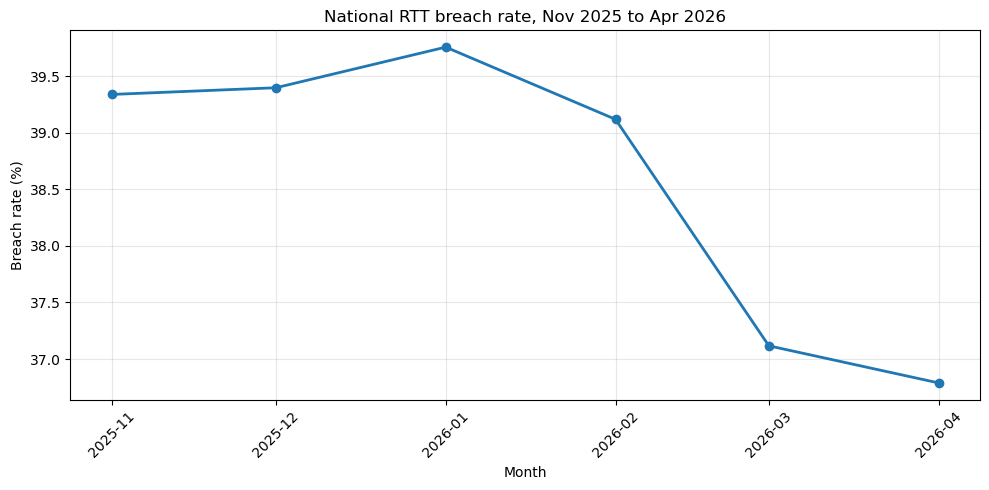

,period_date,breach_rate_pct
0,2025-11-01,39.33799
1,2025-12-01,39.39729
2,2026-01-01,39.75615
3,2026-02-01,39.11822
4,2026-03-01,37.11685
5,2026-04-01,36.78890


In [2]:
national_trend = pd.read_sql('''
    SELECT
        f.period_date,
        SUM(CASE WHEN b.breach_flag = TRUE THEN f.patient_count ELSE 0 END) * 100.0
            / SUM(f.patient_count) AS breach_rate_pct
    FROM fact_rtt_waiting_times f
    JOIN dim_weeks_bands b ON f.band_id = b.band_id
    GROUP BY f.period_date
    ORDER BY f.period_date
''', engine)

national_trend["period_date"] = pd.to_datetime(national_trend["period_date"])

fig, ax = plt.subplots()
ax.plot(national_trend["period_date"], national_trend["breach_rate_pct"], marker="o", linewidth=2)
ax.set_title("National RTT breach rate, Nov 2025 to Apr 2026")
ax.set_ylabel("Breach rate (%)")
ax.set_xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

national_trend

Regional Comparison:

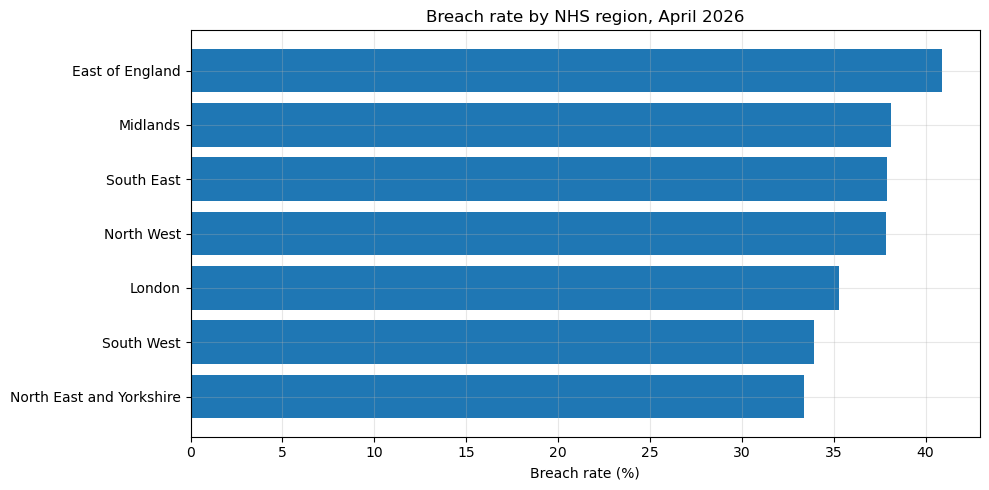

,region_name,breach_rate_pct
0,East of England,40.91484
1,Midlands,38.10594
2,South East,37.91304
3,North West,37.86331
4,London,35.28688
5,South West,33.91552
6,North East and Yorkshire,33.35627


In [3]:
regional = pd.read_sql('''
    SELECT
        r.region_name,
        SUM(CASE WHEN b.breach_flag = TRUE THEN f.patient_count ELSE 0 END) * 100.0
            / SUM(f.patient_count) AS breach_rate_pct
    FROM fact_rtt_waiting_times f
    JOIN dim_providers p ON f.provider_code = p.provider_code
    JOIN dim_icb_region_map m ON p.provider_parent_code = m.icb_code
    JOIN dim_regions r ON m.region_code = r.region_code
    JOIN dim_weeks_bands b ON f.band_id = b.band_id
    WHERE f.period_date = (SELECT MAX(period_date) FROM fact_rtt_waiting_times)
    GROUP BY r.region_name
    ORDER BY breach_rate_pct DESC
''', engine)

fig, ax = plt.subplots()
ax.barh(regional["region_name"], regional["breach_rate_pct"])
ax.set_xlabel("Breach rate (%)")
ax.set_title("Breach rate by NHS region, April 2026")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

regional

Specialty Comparison:

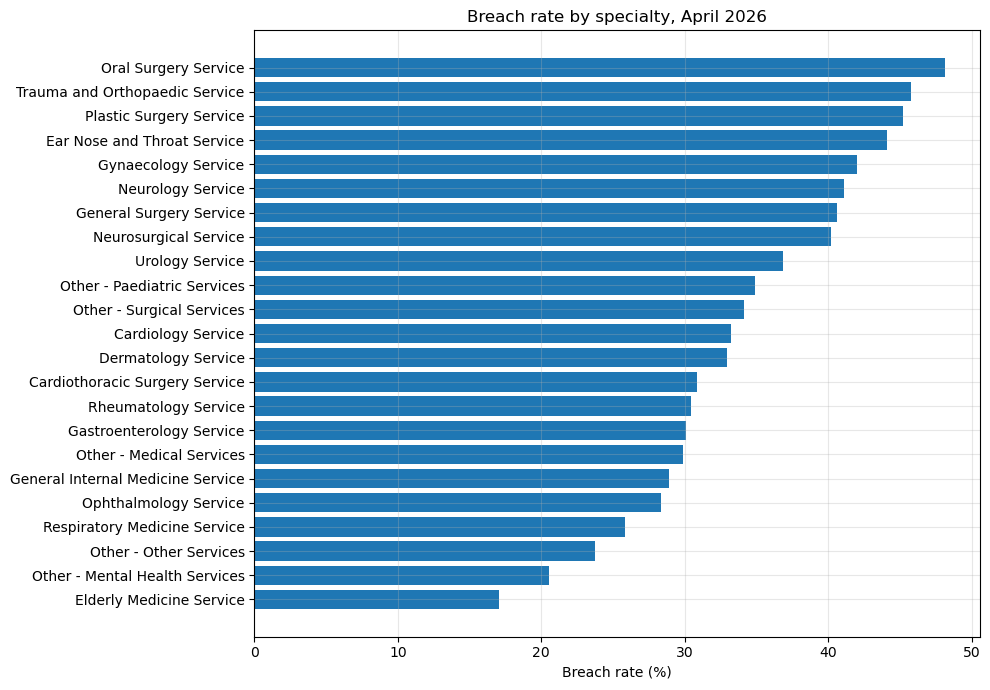

,treatment_function_name,breach_rate_pct,total_patients
0,Oral Surgery Service,48.15587,428548.0
1,Trauma and Orthopaedic Service,45.77850,1245445.0
2,Plastic Surgery Service,45.22754,170122.0
3,Ear Nose and Throat Service,44.10931,757382.0
4,Gynaecology Service,42.00886,743724.0
5,Neurology Service,41.11510,242580.0
6,General Surgery Service,40.60612,570781.0
7,Neurosurgical Service,40.20068,77735.0
8,Urology Service,36.84652,523618.0
9,Other - Paediatric Services,34.92748,429424.0


In [4]:
specialty = pd.read_sql('''
    SELECT
        tf.treatment_function_name,
        SUM(CASE WHEN b.breach_flag = TRUE THEN f.patient_count ELSE 0 END) * 100.0
            / SUM(f.patient_count) AS breach_rate_pct,
        SUM(f.patient_count) AS total_patients
    FROM fact_rtt_waiting_times f
    JOIN dim_treatment_functions tf ON f.treatment_function_code = tf.treatment_function_code
    JOIN dim_weeks_bands b ON f.band_id = b.band_id
    WHERE f.period_date = (SELECT MAX(period_date) FROM fact_rtt_waiting_times)
    GROUP BY tf.treatment_function_name
    ORDER BY breach_rate_pct DESC
''', engine)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(specialty["treatment_function_name"], specialty["breach_rate_pct"])
ax.set_xlabel("Breach rate (%)")
ax.set_title("Breach rate by specialty, April 2026")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

specialty

Provider Size vs Breach Rate:

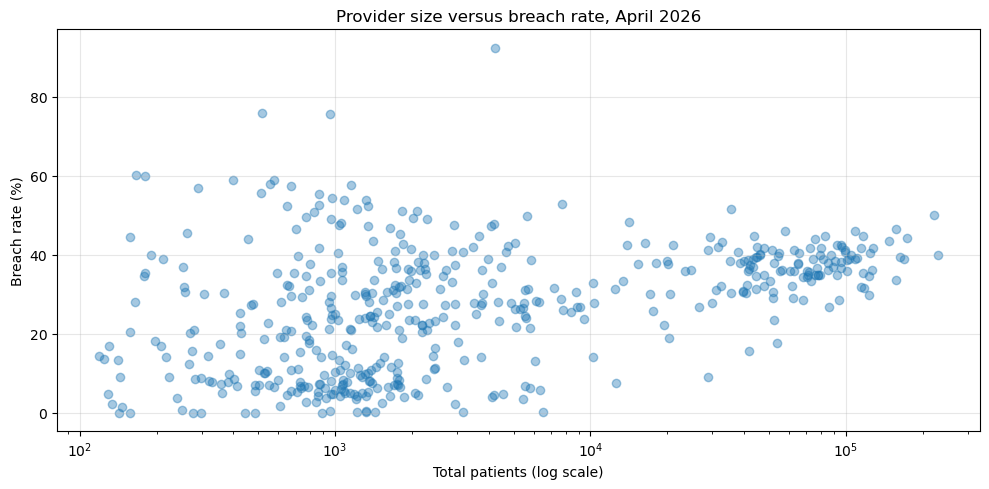

np.float64(0.3506794999223012)

In [5]:
provider_scatter = pd.read_sql('''
    SELECT
        p.provider_code,
        SUM(f.patient_count) AS total_patients,
        SUM(CASE WHEN b.breach_flag = TRUE THEN f.patient_count ELSE 0 END) * 100.0
            / SUM(f.patient_count) AS breach_rate_pct
    FROM fact_rtt_waiting_times f
    JOIN dim_providers p ON f.provider_code = p.provider_code
    JOIN dim_weeks_bands b ON f.band_id = b.band_id
    WHERE f.period_date = (SELECT MAX(period_date) FROM fact_rtt_waiting_times)
    GROUP BY p.provider_code
    HAVING SUM(f.patient_count) >= 100
''', engine)

fig, ax = plt.subplots()
ax.scatter(provider_scatter["total_patients"], provider_scatter["breach_rate_pct"], alpha=0.4)
ax.set_xscale("log")
ax.set_xlabel("Total patients (log scale)")
ax.set_ylabel("Breach rate (%)")
ax.set_title("Provider size versus breach rate, April 2026")
plt.tight_layout()
plt.show()

provider_scatter["total_patients"].corr(provider_scatter["breach_rate_pct"])

## Summary of findings

- **National trend**: breach rate rose from 39.34% in November to a peak of 39.76% in
  January, then fell for 3 consecutive months to 36.79% in April. This is a real,
  sustained decline, not month to month noise, though 6 months is not enough to know
  if this is a genuine seasonal pattern or specific to this period.
- **Region**: a real gap exists between the worst region, East of England at 40.91%,
  and the best, North East and Yorkshire at 33.36%, a 7.5 percentage point spread.
- **Specialty**: the largest gap in the dataset. Oral Surgery breaches at close to 48%,
  against Elderly Medicine at around 17%, nearly a 3x difference. Specialty appears to
  matter far more than region or provider size.
- **Provider size**: only a weak positive correlation with breach rate (r = 0.35).
  Patient volume alone is not a strong predictor, so I would not expect it to carry
  much weight as a standalone feature later on.

Specialty and region look like the two strongest candidates to carry into the feature
engineering and forecasting work next, with provider size as a secondary, weaker
signal rather than a main driver.